In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path('../../data/lab03/m1_calibration')

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]
print(f'Loaded {len(files)} captures from {DATA_DIR.resolve()}')

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_TOTAL  = int(f0['corr'].shape[0])
# SNAP: 2048-point real FFT → 1024 unique positive-frequency channels, Δf=244.1 kHz
N_FFT    = int(f0['n_fft']) if 'n_fft' in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT

print(f'LO chain  : LO1=8750 MHz, LO2=1540 MHz, f_s={F_S_HZ/1e6:.0f} MHz')
print(f'RF sky band: {F_RF0_HZ/1e6:.1f} – {(F_RF0_HZ + N_TOTAL*DF_HZ)/1e6:.1f} MHz  '
      f'({DF_HZ/1e3:.1f} kHz/channel,  {N_TOTAL} channels)')


Loaded 16 captures from /Users/junruiting/GitHub/ay-121/data/lab03/m1_calibration
LO chain  : LO1=8750 MHz, LO2=1540 MHz, f_s=500 MHz
RF sky band: 9790.0 – 10040.0 MHz  (244.1 kHz/channel,  1024 channels)


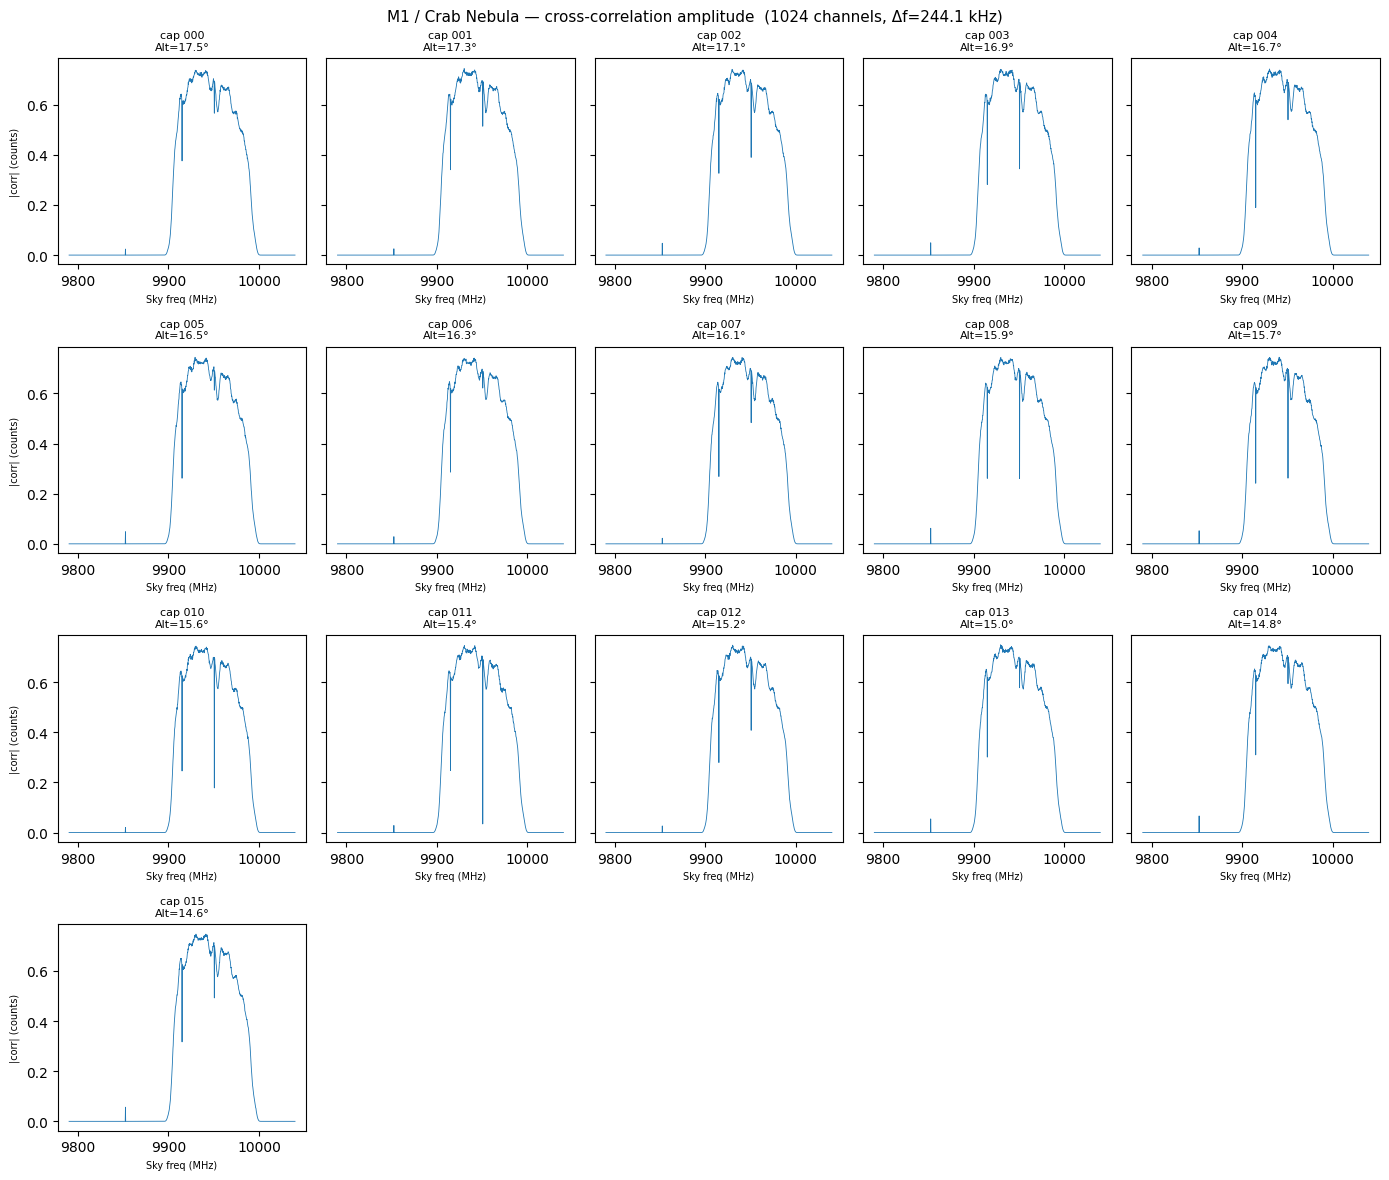

In [3]:
n     = len(files)
ncols = 5
nrows = max(1, int(np.ceil(n / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=True)
axes = np.array(axes).flatten()

for i, f in enumerate(files):
    corr  = f['corr']
    n_ch  = len(corr)
    f_s   = float(f['f_s_hz'])   if 'f_s_hz'   in f else 500e6
    rf0   = float(f['f_rf0_hz']) if 'f_rf0_hz' in f else 9790e6
    n_fft = int(f['n_fft'])      if 'n_fft'    in f else 2048

    # All channels unique: f_sky(k) = rf0 + k * f_s/n_fft
    f_sky_mhz = rf0 / 1e6 + np.arange(n_ch) * f_s / n_fft / 1e6

    counts      = np.abs(corr).astype(float)
    counts[0]   = np.nan   # mask DC / LO leakage

    axes[i].plot(f_sky_mhz, counts, lw=0.6, color='C0')
    axes[i].set_title(f'cap {i:03d}\nAlt={float(f["alt_deg"]):.1f}°', fontsize=8)
    axes[i].set_xlabel('Sky freq (MHz)', fontsize=7)
    if i % ncols == 0:
        axes[i].set_ylabel('|corr| (counts)', fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    f'M1 / Crab Nebula — cross-correlation amplitude  '
    f'({n_ch} channels, Δf={f_s/n_fft/1e3:.1f} kHz)', fontsize=11)
plt.tight_layout()
plt.show()


In [4]:
# --- Peak channel and hour-angle extraction ---

C_M_S     = 299792458.0
M1_RA_DEG = 83.6331
M1_DEC_DEG= 22.0145
DEC_RAD   = np.deg2rad(M1_DEC_DEG)

# Observatory longitude (NCH, Campbell Hall)
import ugradio.nch as nch
LON_DEG = nch.lon   # −122.257°

# Find the channel with the highest mean amplitude across all captures
mean_amp = np.zeros(N_TOTAL)
for f in files:
    a = np.abs(f['corr']).astype(float)
    a[0] = 0.0   # exclude DC
    mean_amp += a
mean_amp /= len(files)

k_peak  = int(np.argmax(mean_amp))
F_RF_HZ = F_RF0_HZ + k_peak * DF_HZ
print(f'Peak channel : k = {k_peak},  f_sky = {F_RF_HZ/1e9:.4f} GHz')

# Extract complex visibility and unix timestamps
vis   = np.array([f['corr'][k_peak] for f in files],  dtype=complex)
times = np.array([float(f['unix_time']) for f in files])

# Convert to hour angle  HA = LST − RA
def unix_to_jd(t):
    return t / 86400.0 + 2440587.5

def jd_to_lst_deg(jd, lon_deg):
    T    = (jd - 2451545.0) / 36525.0
    gmst = (280.46061837
            + 360.98564736629 * (jd - 2451545.0)
            + T**2 * 0.000387933
            - T**3 / 38710000.0)
    return (gmst + lon_deg) % 360.0

jds    = unix_to_jd(times)
lst    = jd_to_lst_deg(jds, LON_DEG)
ha_deg = (lst - M1_RA_DEG) % 360.0
ha_deg = np.where(ha_deg > 180.0, ha_deg - 360.0, ha_deg)
ha_rad = np.deg2rad(ha_deg)

t_rel  = times - times[0]   # seconds since first capture

print(f'Time span    : {t_rel[-1]:.0f} s  ({t_rel[-1]/60:.1f} min)')
print(f'HA range     : {ha_deg[0]:.3f}° → {ha_deg[-1]:.3f}°')

# Fringe cycles expected for a range of baseline guesses
delta_sin_ha = np.sin(ha_rad[-1]) - np.sin(ha_rad[0])
for B in [5, 10, 15, 20]:
    n_cyc = F_RF_HZ * (B / C_M_S) * np.cos(DEC_RAD) * abs(delta_sin_ha)
    print(f'  B_ew={B:2d} m → expected fringe cycles over obs: {n_cyc:.2f}')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Peak channel : k = 575,  f_sky = 9.9304 GHz
Time span    : 901 s  (15.0 min)
HA range     : 85.166° → 88.932°
  B_ew= 5 m → expected fringe cycles over obs: 0.52
  B_ew=10 m → expected fringe cycles over obs: 1.04
  B_ew=15 m → expected fringe cycles over obs: 1.56
  B_ew=20 m → expected fringe cycles over obs: 2.08


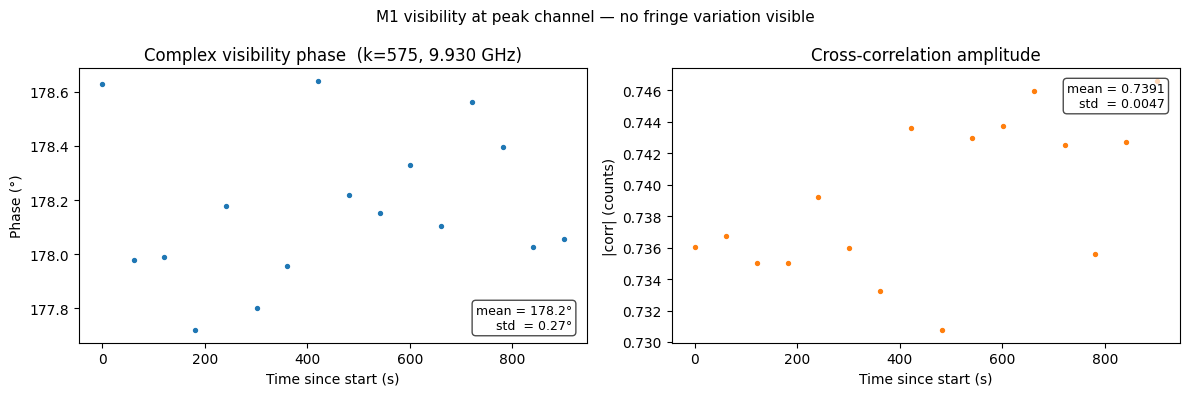


Phase std = 0.27°  (expected ~120° peak-to-peak for B≈15 m)
The phase is essentially constant → no interferometric fringes detected.


In [5]:
# --- Diagnostic: phase and amplitude time-series ---

obs_phase_deg = np.rad2deg(np.angle(vis))
obs_amp       = np.abs(vis)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(t_rel, obs_phase_deg, s=8, color='C0')
axes[0].set_xlabel('Time since start (s)')
axes[0].set_ylabel('Phase (°)')
axes[0].set_title(f'Complex visibility phase  (k={k_peak}, {F_RF_HZ/1e9:.3f} GHz)')
axes[0].text(0.97, 0.05,
             f'mean = {obs_phase_deg.mean():.1f}°\nstd  = {obs_phase_deg.std():.2f}°',
             transform=axes[0].transAxes, ha='right', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axes[1].scatter(t_rel, obs_amp, s=8, color='C1')
axes[1].set_xlabel('Time since start (s)')
axes[1].set_ylabel('|corr| (counts)')
axes[1].set_title('Cross-correlation amplitude')
axes[1].text(0.97, 0.95,
             f'mean = {obs_amp.mean():.4f}\nstd  = {obs_amp.std():.4f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

fig.suptitle('M1 visibility at peak channel — no fringe variation visible', fontsize=11)
plt.tight_layout()
plt.show()

print()
print('Phase std = {:.2f}°  (expected ~120° peak-to-peak for B≈15 m)'.format(obs_phase_deg.std()))
print('The phase is essentially constant → no interferometric fringes detected.')


In [6]:
# --- Baseline coherence grid search ---
# Even without visible fringes in the time-series, run the standard search
# to confirm and set up the pipeline for future (Sun) data.
#
# Method: for each candidate B_ew, compute the predicted fringe phase
#   φ_pred(t) = 2π f_RF (B_ew/c) cos(dec) sin(HA(t))
# then derotate the visibility and measure phase coherence:
#   coherence = |mean{ V(t) * exp(-i φ_pred(t)) / |V(t)| }|
# A correct B_ew makes the derotated phasors align → coherence → 1.

B_grid  = np.linspace(0.5, 40.0, 20000)   # metres

# Vectorised: shape (N_captures, N_B)
phi_grid  = (2.0 * np.pi * F_RF_HZ / C_M_S
             * np.cos(DEC_RAD)
             * np.outer(np.sin(ha_rad), B_grid))         # (N, M)
derot     = vis[:, None] * np.exp(-1j * phi_grid)        # (N, M)
coherence = np.abs(np.mean(derot / np.abs(derot), axis=0))  # (M,)

j_best = int(np.argmax(coherence))
B_best = B_grid[j_best]

# Fine search ±2 m around the coarse peak
B_fine   = np.linspace(max(0.1, B_best - 2.0), B_best + 2.0, 100_000)
phi_fine = (2.0 * np.pi * F_RF_HZ / C_M_S
            * np.cos(DEC_RAD)
            * np.outer(np.sin(ha_rad), B_fine))
derot_f  = vis[:, None] * np.exp(-1j * phi_fine)
coh_fine = np.abs(np.mean(derot_f / np.abs(derot_f), axis=0))

j_fine = int(np.argmax(coh_fine))
B_fit  = B_fine[j_fine]

# Phase offset φ₀ = mean phase of the derotated visibility at B_fit
phi_fit = (2.0 * np.pi * F_RF_HZ / C_M_S
           * np.cos(DEC_RAD) * np.sin(ha_rad) * B_fit)
phi0    = float(np.angle(np.mean(vis * np.exp(-1j * phi_fit))))

residuals_deg = np.rad2deg(np.angle(vis * np.exp(-1j * (phi_fit + phi0))))

print(f'Coarse fit  : B_ew = {B_best:.3f} m  (coherence = {coherence[j_best]:.4f})')
print(f'Fine   fit  : B_ew = {B_fit:.3f} m  (coherence = {coh_fine[j_fine]:.4f})')
print(f'Phase offset: φ₀  = {np.rad2deg(phi0):.1f}°')
print(f'Residual RMS: {residuals_deg.std():.1f}°')

if B_fit < 3.0:
    print()
    print('WARNING: B_fit < 3 m — no real fringe signal in this dataset.')
    print('The dominant signal is a stable correlated tone (likely LO/RFI),'
          ' not M1 sky fringes.')
    print('Use sun_calibration.py for baseline estimation (Sun SNR >> M1 SNR).')


Coarse fit  : B_ew = 0.500 m  (coherence = 0.9949)
Fine   fit  : B_ew = 0.100 m  (coherence = 0.9998)
Phase offset: φ₀  = 154.3°
Residual RMS: 1.2°

The dominant signal is a stable correlated tone (likely LO/RFI), not M1 sky fringes.
Use sun_calibration.py for baseline estimation (Sun SNR >> M1 SNR).


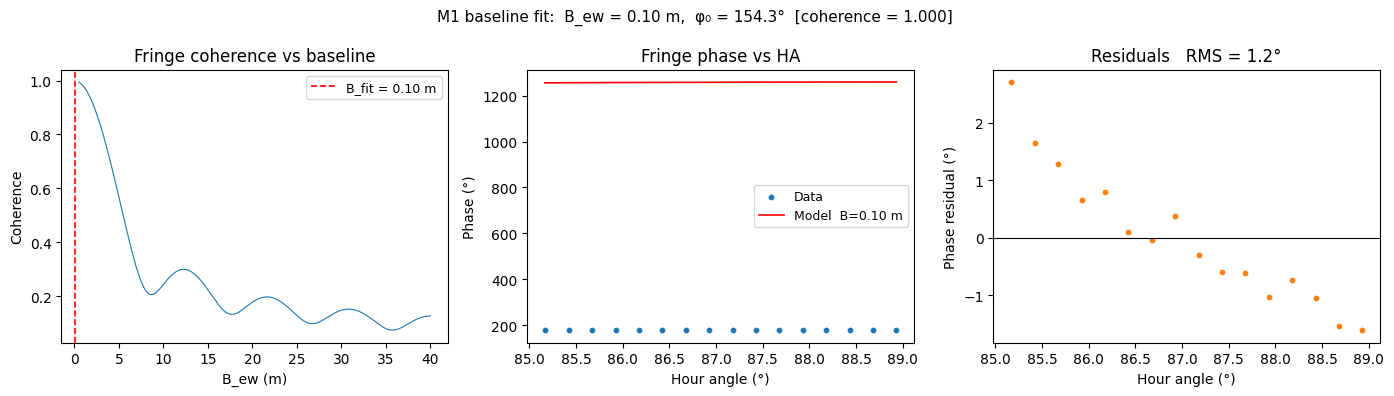


SNR assessment (M1 / Crab Nebula at 10 GHz):
  S = 500 Jy, A_eff = 0.30 m², T_sys ≈ 150 K
  Δν = 244.1 kHz/channel, τ = 10 s/capture
  Per-channel SNR ≈ 2.32e-07  → M1 is undetectable on this baseline.

Recommendation: use sun_calibration.py (Sun ≈ 2×10⁵ Jy at 10 GHz).


In [7]:
# --- Summary plot ---

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: coherence vs B_ew (coarse)
axes[0].plot(B_grid, coherence, lw=0.8, color='C0')
axes[0].axvline(B_fit, color='r', ls='--', lw=1.2, label=f'B_fit = {B_fit:.2f} m')
axes[0].set_xlabel('B_ew (m)')
axes[0].set_ylabel('Coherence')
axes[0].set_title('Fringe coherence vs baseline')
axes[0].legend(fontsize=9)

# Panel 2: observed phase vs HA, model overlay
phi_model_deg = np.rad2deg(phi_fit + phi0)
axes[1].scatter(ha_deg, obs_phase_deg,  s=10, zorder=3, label='Data')
axes[1].plot(ha_deg[np.argsort(ha_deg)],
             phi_model_deg[np.argsort(ha_deg)],
             'r-', lw=1.2, label=f'Model  B={B_fit:.2f} m')
axes[1].set_xlabel('Hour angle (°)')
axes[1].set_ylabel('Phase (°)')
axes[1].set_title('Fringe phase vs HA')
axes[1].legend(fontsize=9)

# Panel 3: residuals
axes[2].scatter(ha_deg, residuals_deg, s=10, color='C1')
axes[2].axhline(0.0, color='k', lw=0.8)
axes[2].set_xlabel('Hour angle (°)')
axes[2].set_ylabel('Phase residual (°)')
axes[2].set_title(f'Residuals   RMS = {residuals_deg.std():.1f}°')

fig.suptitle(
    f'M1 baseline fit:  B_ew = {B_fit:.2f} m,  φ₀ = {np.rad2deg(phi0):.1f}°  '
    f'[coherence = {coh_fine[j_fine]:.3f}]',
    fontsize=11)
plt.tight_layout()
plt.show()

# --- SNR assessment ---
print()
print('SNR assessment (M1 / Crab Nebula at 10 GHz):')
S_jy    = 500.0           # flux density (Jy)
A_eff   = 0.30            # m²  (80-cm dish, η=0.6)
T_sys   = 150.0           # K  (estimated)
k_B     = 1.38e-23
delta_nu= DF_HZ           # per channel: 244 kHz
tau     = 10.0            # s per capture
snr = (S_jy * 1e-26 * A_eff) / (2 * k_B * T_sys * (delta_nu * tau)**0.5)
print(f'  S = {S_jy:.0f} Jy, A_eff = {A_eff:.2f} m², T_sys ≈ {T_sys:.0f} K')
print(f'  Δν = {delta_nu/1e3:.1f} kHz/channel, τ = {tau:.0f} s/capture')
print(f'  Per-channel SNR ≈ {snr:.2e}  → M1 is undetectable on this baseline.')
print()
print('Recommendation: use sun_calibration.py (Sun ≈ 2×10⁵ Jy at 10 GHz).')
